In [1]:
# list the file names in the folder /home/yuchialin/JWST/twhya/356W/data_nirccam_twhya/uncal

import os
folder = '/npool/nvme/yuchialin/JWST/twhya/356W/data_nircam_twhya/uncal'
file_names = os.listdir(folder)
# sort the file names
file_names.sort()
output = ''
for name in file_names:
    if name.endswith('.fits'):
        output += name[:-11] + ', '
print(output)

jw01179005001_03106_00001_nrcalong, jw01179005001_03107_00001_nrcalong, jw01179008001_03106_00001_nrcalong, jw01179008001_03107_00001_nrcalong, jw03840003001_03108_00001_nrcalong, jw03840003001_03108_00002_nrcalong, jw03840003001_03108_00003_nrcalong, jw03840003001_03108_00004_nrcalong, jw03840003001_03108_00005_nrcalong, jw03840003001_03108_00006_nrcalong, jw03840003001_03108_00007_nrcalong, jw03840003001_03108_00008_nrcalong, jw03840003001_03108_00009_nrcalong, jw04558006001_03108_00001_nrcalong, jw04558006001_03108_00002_nrcalong, jw04558006001_03108_00003_nrcalong, jw04558006001_03108_00004_nrcalong, jw04558006001_03108_00005_nrcalong, jw04558006001_03108_00006_nrcalong, jw04558006001_03108_00007_nrcalong, jw04558006001_03108_00008_nrcalong, jw04558006001_03108_00009_nrcalong, jw04558009001_03108_00001_nrcalong, jw04558009001_03108_00002_nrcalong, jw04558009001_03108_00003_nrcalong, jw04558009001_03108_00004_nrcalong, jw04558009001_03108_00005_nrcalong, jw04558009001_03108_00006_nr

In [3]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [4]:
import os
import numpy as np
import subprocess

import spaceKLIP

import matplotlib
matplotlib.rcParams.update({'font.size': 14})
%matplotlib inline

import webbpsf_ext
webbpsf_ext.setup_logging('WARN', verbose=False)

In [5]:
data_root = 'data_nircam_twhya'

In [6]:
# Name the root directory where we will keep the data for this tutorial.
filt = 'F356W'  # Set to None to disable filter selection and load all filters.

In [7]:
# Initialize spaceKLIP database.
database = spaceKLIP.database.create_database(
                                    input_dir=os.path.join(data_root, 'uncal'),
                                    output_dir=data_root,
                                    filt=filt,
                                    pid=None)

2026-01-19 12:12:25,442 - CRDS - INFO -  Calibration SW Found: jwst 1.17.1 (/npool/nvme/yuchialin/miniconda3/envs/spaceklip/lib/python3.11/site-packages/jwst-1.17.1.dist-info)


[spaceKLIP.database:INFO] --> Identified 1 concatenation(s)
[spaceKLIP.database:INFO]   --> Concatenation 1: JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
TYPE  EXP_TYPE DATAMODL TELESCOP ... PIXAR_SR BUNIT      ROLL_REF      BLURFWHM
---- --------- -------- -------- ... -------- ----- ------------------ --------
 SCI NRC_CORON   STAGE0     JWST ...      nan    DN 332.07781588204216      nan
 SCI NRC_CORON   STAGE0     JWST ...      nan    DN  342.0772393600343      nan
 REF NRC_CORON   STAGE0     JWST ...      nan    DN 19.994621641328305      nan
 REF NRC_CORON   STAGE0     JWST ...      nan    DN  19.99464667335166      nan
 REF NRC_CORON   STAGE0     JWST ...      nan    DN 19.994634639386696      nan
 REF NRC_CORON   STAGE0     JWST ...      nan    DN  19.99464488279737      nan
 REF NRC_CORON   STAGE0     JWST ...      nan    DN  19.99464282577306      nan
 REF NRC_CORON   STAGE0     JWST ...      nan    DN 19.994627555557376      nan
 REF NRC_CORON   STAGE0     JWST ..

In [8]:
database.summarize()

# Check how many files we have in the database

NIRCAM_F356W_MASK335R
	STAGE0: 29 files;	2 SCI, 27 REF


In [9]:
# COMPREHENSIVE SUMMARY OF REFERENCE IMAGES AND STARS
print("="*60)
print("REFERENCE IMAGES AND STARS ANALYSIS")
print("="*60)

# Get the data
concat_key = 'JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R'
table = database.obs[concat_key]
df = table.to_pandas()

# Basic counts
total_ref = len(df[df['TYPE'] == 'REF'])
total_sci = len(df[df['TYPE'] == 'SCI'])

print(f"TOTAL IMAGES:")
print(f"  • Reference images: {total_ref}")
print(f"  • Science images: {total_sci}")
print(f"  • Total: {total_ref + total_sci}")
print()

# Reference star analysis
ref_df = df[df['TYPE'] == 'REF']
ref_star_counts = ref_df['TARGPROP'].value_counts()

print(f"REFERENCE STARS:")
print(f"  • Number of different reference stars: {len(ref_star_counts)}")
print(f"  • Reference star breakdown:")
for i, (star, count) in enumerate(ref_star_counts.items(), 1):
    percentage = (count/total_ref)*100
    print(f"    {i}. {star}: {count} images ({percentage:.1f}%)")
print()

# Science target
sci_df = df[df['TYPE'] == 'SCI']
sci_targets = sci_df['TARGPROP'].unique()
print(f"SCIENCE TARGET:")
print(f"  • Target name: {sci_targets[0]}")
print(f"  • Number of science images: {total_sci}")
print()

# Observation setup
print(f"OBSERVATION DETAILS:")
print(f"  • Filter: {df['FILTER'].iloc[0]}")
print(f"  • Coronagraph mask: {df['CORONMSK'].iloc[0]}")
print(f"  • Pupil mask: {df['PUPIL'].iloc[0]}")
print(f"  • Detector: {df['DETECTOR'].iloc[0]}")
print(f"  • Subarray: {df['SUBARRAY'].iloc[0]}")
print()

# Program IDs (from filenames)
ref_program_ids = set()
sci_program_ids = set()

for filename in ref_df['FITSFILE']:
    # Extract program ID from filename (format: jw[PROGRAM_ID]...)
    program_id = filename.split('/')[-1].split('_')[0][2:7]  # Remove 'jw' prefix
    ref_program_ids.add(program_id)

for filename in sci_df['FITSFILE']:
    program_id = filename.split('/')[-1].split('_')[0][2:7]
    sci_program_ids.add(program_id)

print(f"PROGRAM IDs:")
print(f"  • Reference observations from program(s): {', '.join(sorted(ref_program_ids))}")
print(f"  • Science observations from program(s): {', '.join(sorted(sci_program_ids))}")

print("="*60)

REFERENCE IMAGES AND STARS ANALYSIS
TOTAL IMAGES:
  • Reference images: 27
  • Science images: 2
  • Total: 29

REFERENCE STARS:
  • Number of different reference stars: 2
  • Reference star breakdown:
    1. HD_33093: 18 images (66.7%)
    2. V-AP-COL: 9 images (33.3%)

SCIENCE TARGET:
  • Target name: TW-HYA
  • Number of science images: 2

OBSERVATION DETAILS:
  • Filter: F356W
  • Coronagraph mask: MASK335R
  • Pupil mask: MASKRND
  • Detector: NRCALONG
  • Subarray: SUB320A335R

PROGRAM IDs:
  • Reference observations from program(s): 03840, 04558
  • Science observations from program(s): 01179


In [10]:
spaceKLIP.coron1pipeline.run_obs(database=database,
                       steps={'group_scale': {'skip': False},
                              'dq_init': {'skip': False},
                              'saturation': {'n_pix_grow_sat': 1,
                                             'grow_diagonal': False},
                              'ipc': {'skip': True},
                              'superbias':{'skip': False},
                              'refpix': {'odd_even_columns': True,
                                         'odd_even_rows': True,
                                         'nlower': 4,
                                         'nupper': 4,
                                         'nleft': 4,
                                         'nright': 4,
                                         'nrow_off': 0,
                                         'ncol_off': 0},
                              'linearity': {'skip': False},
                              'dark_current': {'skip': True},
                              'persistence': {'skip': True},
                              'jump': {'rejection_threshold': 4.,
                                       'three_group_rejection_threshold': 4.,
                                       'four_group_rejection_threshold': 4.,
                                       'maximum_cores': 'all'},
                              'subtract_1overf': {'model_type': 'savgol',
                                                  'sat_frac': 0.5,
                                                  'combine_ints': True,
                                                  'vertical_corr': True,
                                                  'nproc': 4},
                              'ramp_fit': {'save_calibrated_ramp': False,
                                          'maximum_cores': 'all'},
                              'gain_scale': {'skip': False}},
                       subdir='stage1')

[spaceKLIP.coron1pipeline:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw01179005001_03106_00001_nrcalong_uncal.fits
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw01179008001_03106_00001_nrcalong_uncal.fits
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw03840003001_03108_00001_nrcalong_uncal.fits
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw03840003001_03108_00002_nrcalong_uncal.fits
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw03840003001_03108_00003_nrcalong_uncal.fits
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw03840003001_03108_00004_nrcalong_uncal.fits
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw03840003001_03108_00005_nrcalong_uncal.fits
[spaceKLIP.coron1pipeline:INFO]   --> Coron1Pipeline: processing jw03840003001_03108_00006_nrcalong_uncal.fits
[space

In [11]:
database.summarize()

NIRCAM_F356W_MASK335R
	STAGE1: 29 files;	2 SCI, 27 REF


In [12]:
import spaceKLIP.__init__
print(spaceKLIP.__init__.__version__)

2.1.1.dev111+g6e5b1f949


In [13]:
spaceKLIP.plotting.display_coron_dataset(
    database,
    restrict_to={
        'FILTER': filt,  # Sort by filter.
        'TYPE': ['SCI']  # Sort by file type SCI/REF.
    },
    interactive=True,  # Static or interactive plots?
    zoom_center=3,  # Optional zoom factor; set to None to disable.
    vmin=0, vmax=1e3,  # Define the min/max values for consistent image scaling.
    save_filename='twhya_f356W_stage1.pdf'  # Save plots to PDF.
)

IntSlider(value=0, description='Image  Index:', max=1)

Output()

In [14]:
database = spaceKLIP.database.create_database(
                                    input_dir=os.path.join(data_root, 'stage1'),
                                    file_type='rateints.fits',
                                    output_dir=data_root,
                                    filt=filt,
                                    pid=None)

[spaceKLIP.database:INFO] --> Identified 1 concatenation(s)
[spaceKLIP.database:INFO]   --> Concatenation 1: JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
TYPE  EXP_TYPE DATAMODL TELESCOP ... PIXAR_SR BUNIT      ROLL_REF      BLURFWHM
---- --------- -------- -------- ... -------- ----- ------------------ --------
 SCI NRC_CORON   STAGE1     JWST ...      nan  DN/s 332.07781588204216      nan
 SCI NRC_CORON   STAGE1     JWST ...      nan  DN/s  342.0772393600343      nan
 REF NRC_CORON   STAGE1     JWST ...      nan  DN/s 19.994621641328305      nan
 REF NRC_CORON   STAGE1     JWST ...      nan  DN/s  19.99464667335166      nan
 REF NRC_CORON   STAGE1     JWST ...      nan  DN/s 19.994634639386696      nan
 REF NRC_CORON   STAGE1     JWST ...      nan  DN/s  19.99464488279737      nan
 REF NRC_CORON   STAGE1     JWST ...      nan  DN/s  19.99464282577306      nan
 REF NRC_CORON   STAGE1     JWST ...      nan  DN/s 19.994627555557376      nan
 REF NRC_CORON   STAGE1     JWST ..

In [15]:
spaceKLIP.coron2pipeline.run_obs(database=database,
                                steps={'bkg_subtract': {'skip': False},
                                       'assign_wcs': {'skip': False},
                                       'flat_field': {'skip': False},
                                       'photom': {'skip': False},
                                       'outlier_detection': {'skip': False}},
                                subdir='stage2')

[spaceKLIP.coron2pipeline:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw01179005001_03106_00001_nrcalong_rateints.fits
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw01179008001_03106_00001_nrcalong_rateints.fits
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw03840003001_03108_00001_nrcalong_rateints.fits
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw03840003001_03108_00002_nrcalong_rateints.fits
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw03840003001_03108_00003_nrcalong_rateints.fits
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw03840003001_03108_00004_nrcalong_rateints.fits
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw03840003001_03108_00005_nrcalong_rateints.fits
[spaceKLIP.coron2pipeline:INFO]   --> Coron2Pipeline: processing jw03840003001_03108_00006_nrcal

In [16]:
database.summarize()

NIRCAM_F356W_MASK335R
	STAGE2: 29 files;	2 SCI, 27 REF


In [17]:
spaceKLIP.plotting.display_coron_dataset(
    database,
    restrict_to={
        'FILTER': filt,  # Sort by filter.
        'TYPE': ['SCI']  # Sort by file type SCI/REF.
    },
    interactive=True,  # Static or interactive plots?
    zoom_center=3,  # Optional zoom factor; set to None to disable.
    vmin=0, vmax=1e3,  # Define the min/max values for consistent image scaling.
    save_filename='twhya_f356W_stage2.pdf'  # Save plots to PDF.
)

IntSlider(value=0, description='Image  Index:', max=1)

Output()

In [18]:
database = spaceKLIP.database.create_database(
                                    input_dir=os.path.join(data_root, 'stage2'),
                                    file_type='calints.fits',
                                    output_dir=data_root,
                                    filt=filt,
                                    pid=None)

[spaceKLIP.database:INFO] --> Identified 1 concatenation(s)
[spaceKLIP.database:INFO]   --> Concatenation 1: JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
TYPE  EXP_TYPE DATAMODL TELESCOP ... BUNIT       ROLL_REF      BLURFWHM
---- --------- -------- -------- ... ------ ------------------ --------
 SCI NRC_CORON   STAGE2     JWST ... MJy/sr 332.07781588204216      nan
 SCI NRC_CORON   STAGE2     JWST ... MJy/sr  342.0772393600343      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr 19.994621641328305      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr  19.99464667335166      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr 19.994634639386696      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr  19.99464488279737      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr  19.99464282577306      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr 19.994627555557376      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr 19.994628349671505      nan
 REF NRC_CORON   STAGE2     JWST ... MJy/sr

In [19]:
# Initialize spaceKLIP image manipulation tools class.
imageTools = spaceKLIP.imagetools.ImageTools(database=database)


In [20]:
# Median-subtract each frame to mitigate uncalibrated bias drifts.
imageTools.subtract_median(types=['SCI', 'SCI_TA', 'SCI_BG', 'REF', 'REF_TA', 'REF_BG'],
                           subdir='medsub')

[spaceKLIP.imagetools:INFO] Median subtraction using method=border
[spaceKLIP.imagetools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.imagetools:INFO]   --> Median subtraction: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Median subtraction: mean of frame median = 0.04
[spaceKLIP.imagetools:INFO]   --> Median subtraction: jw01179008001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Median subtraction: mean of frame median = 0.04
[spaceKLIP.imagetools:INFO]   --> Median subtraction: jw03840003001_03108_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Median subtraction: mean of frame median = 0.02
[spaceKLIP.imagetools:INFO]   --> Median subtraction: jw03840003001_03108_00002_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Median subtraction: mean of frame median = 0.05
[spaceKLIP.imagetools:INFO]   --> Median subtraction: jw03840003001_03108_00003_nrcalong_calint

In [21]:
# Compare before and after median subtraction.

spaceKLIP.plotting.display_image_comparisons(
    database,
    ['stage2', 'medsub'],  # Subdirectories to look for files in.
    restrict_to={'FILTER': filt,  # Sort by filter.
                 'TYPE': ['SCI']  # Sort by file type SCI/REF.
    },
    interactive=True,  # Static or interactive plots?
    vmin=0, vmax=10,  # Define the min/max values for consistent image scaling.
    save_filename='twhya_medsub_f356W_comparison.pdf')

IntSlider(value=0, description='Image Index:', max=1)

Output()

In [22]:
# Fix bad pixels using custom spaceKLIP routines. Multiple routines can be
# combined in a custom order by joining them with a + sign.
# - sigclip: use sigma clipping to find additional bad pixels.
# - custom: use custom map to find additional bad pixels.
# - timemed: replace pixels which are only bad in some frames with their
#            median value from the good frames.
# - localmed: replace bad pixels with the median of surrounding good
#            pixels.
# - medfilt: replace bad pixels with an image plane median filter.

# - shift_x/y: Define the range of pixel shifts (left/right and up/down)
# used in sigma clipping to compare a pixel with its neighbors and identify deviations.

imageTools.fix_bad_pixels(method='sigclip+timemed+localmed+medfilt',
                          sigclip_kwargs={'sigclip': 3,
                                          'shift_x': [-3, 0, 3],
                                          'shift_y': [-3, 0, 3]},
                          custom_kwargs={},
                          timemed_kwargs={},
                          localmed_kwargs={'shift_x': [-1, 0, 1],
                                        'shift_y': [-1, 0, 1]},
                          medfilt_kwargs={'size': 4},
                          subdir='bpcleaned')

[spaceKLIP.imagetools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.imagetools:INFO]   --> Method sigclip: jw01179005001_03106_00001_nrcalong_calints.fits
Frame 16/16, iteration 4
[spaceKLIP.imagetools:INFO]   --> Method sigclip: identified 238497 additional bad pixel(s) -- 14.56%
[spaceKLIP.imagetools:INFO]   --> Method timemed: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Method timemed: fixing 237822 bad pixel(s) -- 14.52%
[spaceKLIP.imagetools:INFO]   --> Method localmed: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Method localmed: fixing 25840 bad pixel(s) -- 1.58%
[spaceKLIP.imagetools:INFO]   --> Method medfilt: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Method medfilt: fixing 0 bad pixel(s) -- 0.00%
[spaceKLIP.imagetools:INFO]   --> Method sigclip: jw01179008001_03106_00001_nrcalong_calints.fits
Frame 16/16, iteration 4
[

In [23]:
# Compare how well each cleaning method did to replace bad pixels.

spaceKLIP.plotting.display_image_comparisons(
    database,
    ['medsub', 'bpcleaned'],  # Subdirectories to look for files in.
    restrict_to={'FILTER': filt,  # Sort by filter.
                 'TYPE': ['SCI']  # Sort by file type SCI/REF.
    },
    interactive=True,  # Static or interactive plots?
    vmin=0, vmax=10, # Define the min/max values for consistent image scaling.
    save_filename='twhya_clean_bp_f356W_comparison.pdf')

IntSlider(value=0, description='Image Index:', max=1)

Output()

In [24]:
# This changes only the mask center information in the database table.
# No change in the observed data.
imageTools.update_nircam_centers()

[spaceKLIP.imagetools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: using CRPIX from database
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: old = (150.20, 174.60), new = (150.98, 174.44)
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: jw01179008001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: using CRPIX from database
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: old = (150.20, 174.60), new = (150.98, 174.44)
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: jw03840003001_03108_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Update NIRCam coronagraphy centers: using CRPIX from database
[spaceKLIP.imagetools:

[spaceKLIP.imagetools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter frames: generating WebbPSF image for absolute centering (this might take a while)
[spaceKLIP.psf:INFO] Generating on-axis and off-axis PSFs...
[spaceKLIP.psf:INFO]   Done.
[spaceKLIP.imagetools:INFO]   --> Recenter frames: star offset between frame 0 and coronagraph center (dx, dy) = (0.044, -0.165) pix
[spaceKLIP.imagetools:INFO]   --> Recenter frames: star offset between frame 1 and coronagraph center (dx, dy) = (0.015, -0.165) pix
[spaceKLIP.imagetools:INFO]   --> Recenter frames: star offset between frame 2 and coronagraph center (dx, dy) = (0.013, -0.160) pix
[spaceKLIP.imagetools:INFO]   --> Recenter frames: star offset between frame 3 and coronagraph center (dx, dy) = (0.038, -0.159) pix
[spaceKLIP.imagetools:INFO]   --> Recenter frames: s

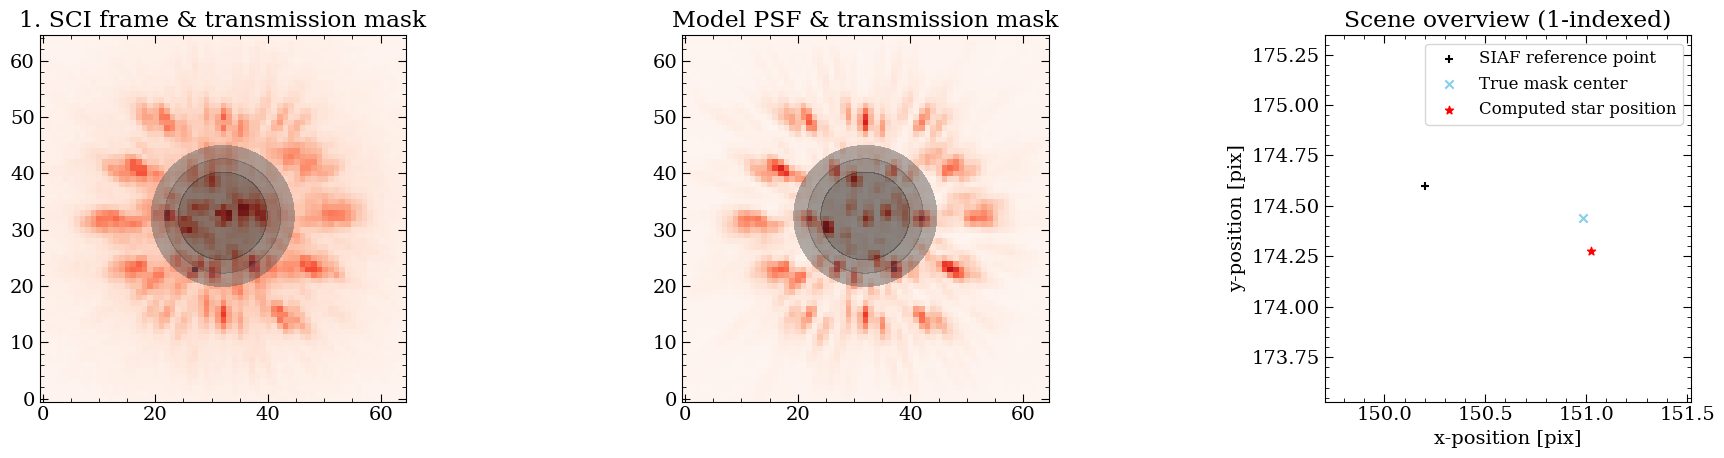

[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter frames: median required shift = 1043.72 mas
[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw01179008001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw01179008001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter frames: median required shift = 1043.72 mas
[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw03840003001_03108_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw03840003001_03108_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter frames: median required shift = 1043.72 mas
[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw03840003001_03108_00002_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter frames: jw03840003001_03108_00002_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Recenter fra

In [25]:
imageTools.recenter_frames(spectral_type='M0V')

# The spectral type is used to make a more accurate PSF simulation for the star.
# This step changes the pixel data in the first science frame to center it.
# The other subsequent frames are shifted identically. I.e. the shift to center
# the first SCI frame is applied to all SCI and REF frames.

In [26]:
!ls data_nircam_twhya/recentered/*pdf

data_nircam_twhya/recentered/jw01179005001_03106_00001_nrcalong_calints.pdf


[spaceKLIP.imagetools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.imagetools:INFO]   --> Align frames: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Align frames: median required shift = 0.26 mas
[spaceKLIP.imagetools:INFO]   --> Align frames: jw01179008001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Align frames: median required shift = 14.30 mas
[spaceKLIP.imagetools:INFO]   --> Align frames: jw03840003001_03108_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Align frames: median required shift = 13.90 mas
[spaceKLIP.imagetools:INFO]   --> Align frames: jw03840003001_03108_00002_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Align frames: median required shift = 33.12 mas
[spaceKLIP.imagetools:INFO]   --> Align frames: jw03840003001_03108_00003_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Align frames: median required shift = 32.79 mas
[spaceKLI

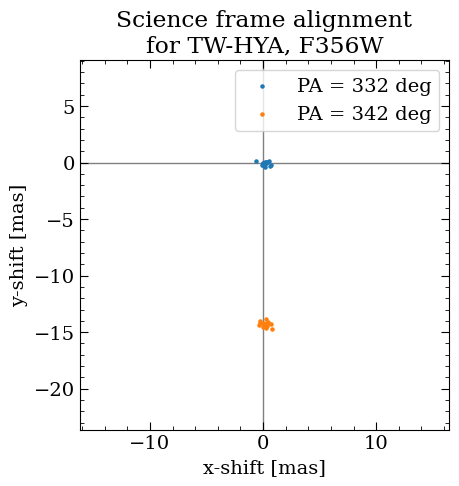

[spaceKLIP.imagetools:INFO]  Plot saved in data_nircam_twhya/aligned/JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R_align_ref.pdf


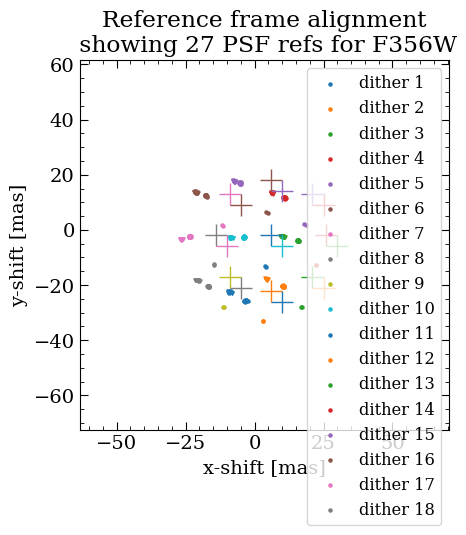

In [27]:
# Align Frames Use image registration to align all frames in a concatenation to the
# first science frame in that concatenation.
imageTools.align_frames(method='fourier',
                        kwargs={},
                        subdir='aligned')

In [28]:
# This step also outputs plots that show the results of the alignment.
!ls data_nircam_twhya/aligned/*pdf

data_nircam_twhya/aligned/JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R_align_ref.pdf
data_nircam_twhya/aligned/JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R_align_sci.pdf


In [29]:
# Compare how well recentering and alignment did.

spaceKLIP.plotting.display_image_comparisons(
    database,
    ['recentered', 'aligned'],  # Subdirectories to look for files in.
    restrict_to={'FILTER': filt,  # Sort by filter.
                 'TYPE': ['SCI', 'REF']  # Sort by file type SCI/REF.
    },
    subtract_first=True,  # Subtract the first science frame to check alignment.
    interactive=True,  # Static or interactive plots?
    # Define the min/max/stretch values for consistent image scaling.
    # vmin=-0.5, vmax=0.5, stretch=0.05,
    save_filename='twhya_recenter_vs_align_f356W_comparison.pdf')

IntSlider(value=1, description='Image Index:', max=28, min=1)

Output()

In [30]:
# Pad all frames.
imageTools.pad_frames(npix=80,
                      cval=np.nan,
                      types=['SCI', 'SCI_BG', 'REF', 'REF_BG'],
                      subdir='padded')

[spaceKLIP.imagetools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.imagetools:INFO]   --> Frame padding: jw01179005001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Frame padding: old shape = (320, 320), new shape = (480, 480), fill value = nan
[spaceKLIP.imagetools:INFO]   --> Frame padding: jw01179008001_03106_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Frame padding: old shape = (320, 320), new shape = (480, 480), fill value = nan
[spaceKLIP.imagetools:INFO]   --> Frame padding: jw03840003001_03108_00001_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Frame padding: old shape = (320, 320), new shape = (480, 480), fill value = nan
[spaceKLIP.imagetools:INFO]   --> Frame padding: jw03840003001_03108_00002_nrcalong_calints.fits
[spaceKLIP.imagetools:INFO]   --> Frame padding: old shape = (320, 320), new shape = (480, 480), fill value = nan
[spaceKLIP.imagetools:INFO]   --> Frame padding: jw038

In [31]:
spaceKLIP.plotting.display_coron_dataset(
    database,
    restrict_to={'FILTER': filt,  # Sort by filter.
                 'TYPE': ['SCI']  # Sort by file type SCI/REF.
    },
    interactive=True,  # Set to False for static plots.
    zoom_center=3,  # Optional zoom factor; set to None to disable.
    bbox_color=None,  # Remove background text boxes.
    save_filename='twhya_f356W_stage2_cleaned.pdf'  # Save plots to PDF.
)

IntSlider(value=0, description='Image  Index:', max=1)

Output()

In [32]:
# Run pyKLIP pipeline. Additional parameters for klip_dataset function can
# be passed using kwargs parameter.
spaceKLIP.pyklippipeline.run_obs(database=database,
                       kwargs={'mode': ['ADI', 'RDI', 'ADI+RDI'],
                               'annuli': [1],
                               'subsections': [1],
                               'numbasis': [1, 2, 5, 10, 20, 50],
                               'algo': 'klip',
                               'save_rolls': True},
                       subdir='klipsub')

[spaceKLIP.pyklippipeline:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.pyklippipeline:INFO]   --> pyKLIP: mode = ADI, annuli = 1, subsections = 1
Begin align and scale images for each wavelength
Wavelength 3.593e-06 with index 0 has finished align and scale. Queuing for KLIP
Total number of tasks for KLIP processing is 1


  0%|          | 0/1 [00:00<?, ?it/s]

Closing threadpool
Derotating Images...
Writing Images to directory /npool/nvme/yuchialin/JWST/twhya/356W/data_nircam_twhya/klipsub
wavelength collapsing reduced data of shape (b, N, wv, y, x):(6, 32, 1, 480, 480)
[spaceKLIP.pyklippipeline:INFO]   --> pyKLIP: mode = RDI, annuli = 1, subsections = 1
Begin align and scale images for each wavelength
Wavelength 3.593e-06 with index 0 has finished align and scale. Queuing for KLIP
Total number of tasks for KLIP processing is 1


  0%|          | 0/1 [00:00<?, ?it/s]

Closing threadpool
Derotating Images...
Writing Images to directory /npool/nvme/yuchialin/JWST/twhya/356W/data_nircam_twhya/klipsub
wavelength collapsing reduced data of shape (b, N, wv, y, x):(6, 32, 1, 480, 480)
[spaceKLIP.pyklippipeline:INFO]   --> pyKLIP: mode = ADI+RDI, annuli = 1, subsections = 1
Begin align and scale images for each wavelength
Wavelength 3.593e-06 with index 0 has finished align and scale. Queuing for KLIP
Total number of tasks for KLIP processing is 1


  0%|          | 0/1 [00:00<?, ?it/s]

Closing threadpool
Derotating Images...
Writing Images to directory /npool/nvme/yuchialin/JWST/twhya/356W/data_nircam_twhya/klipsub
wavelength collapsing reduced data of shape (b, N, wv, y, x):(6, 32, 1, 480, 480)
[spaceKLIP.database:INFO] --> Identified 1 concatenation(s)
[spaceKLIP.database:INFO]   --> Concatenation 1: JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
 TYPE   EXP_TYPE DATAMODL TELESCOP ... SUBSECTS    KLMODES     BUNIT  BLURFWHM
------ --------- -------- -------- ... -------- -------------- ------ --------
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan


In [33]:
database.summarize()

NIRCAM_F356W_MASK335R
	STAGE2: 29 files;	2 SCI, 27 REF
	STAGE3: 3 files;	3 PYKLIP


In [34]:
database = spaceKLIP.database.create_database(
                                    input_dir=os.path.join(data_root, 'klipsub'),
                                    file_type='*KLmodes-all.fits',
                                    output_dir=data_root,
                                    readlevel=3,
                                    pid=1179)

[spaceKLIP.database:INFO] --> Identified 1 concatenation(s)
[spaceKLIP.database:INFO]   --> Concatenation 1: JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
 TYPE   EXP_TYPE DATAMODL TELESCOP ... SUBSECTS    KLMODES     BUNIT  BLURFWHM
------ --------- -------- -------- ... -------- -------------- ------ --------
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan


In [35]:
database.summarize()

NIRCAM_F356W_MASK335R
	STAGE2: 29 files;	2 SCI, 27 REF
	STAGE3: 3 files;	3 PYKLIP


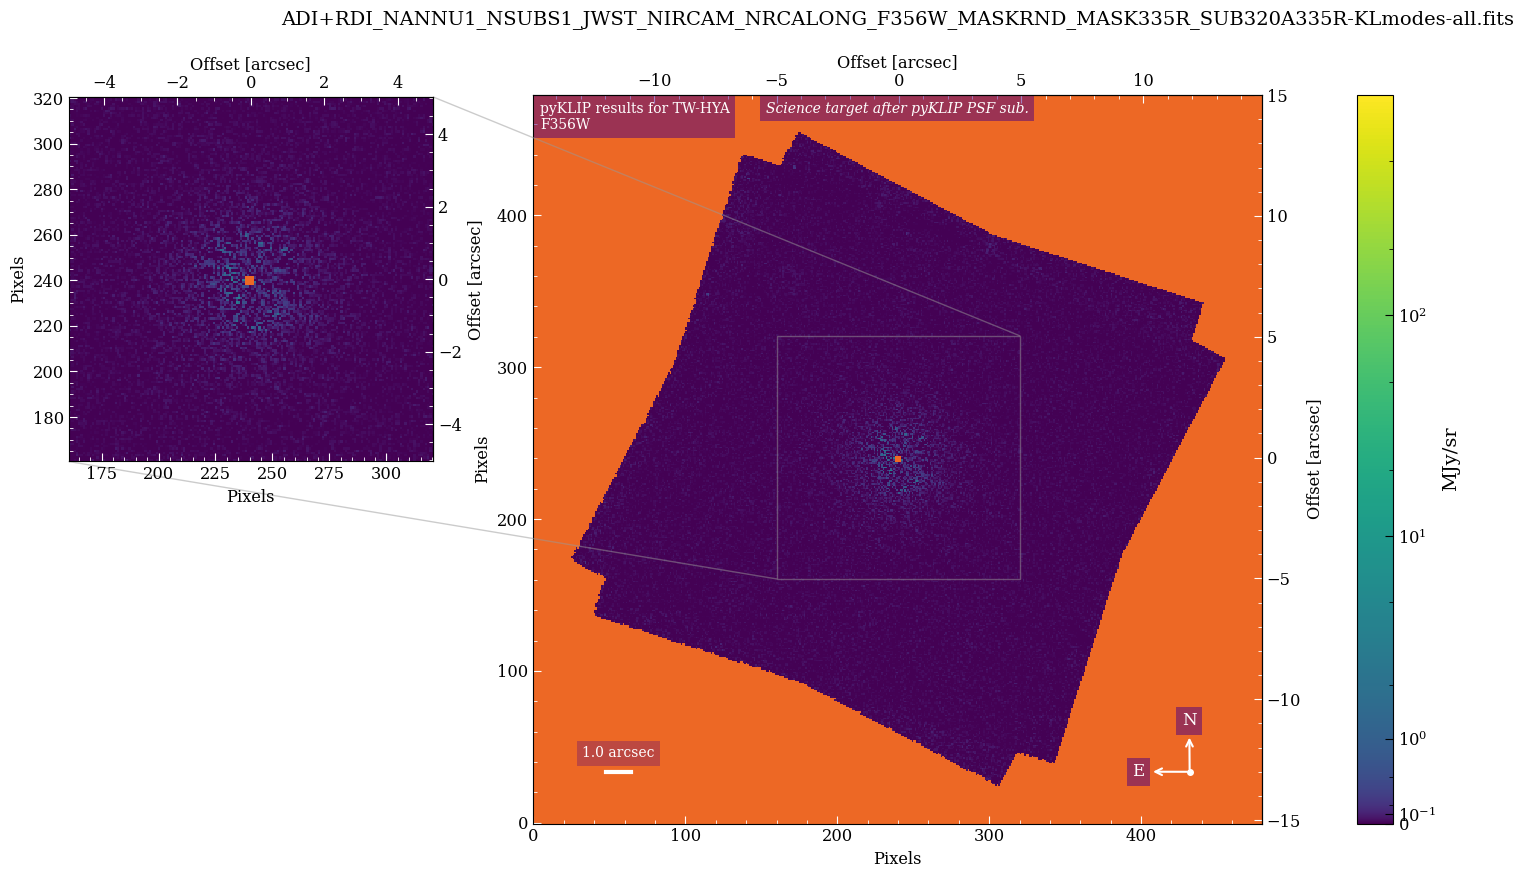

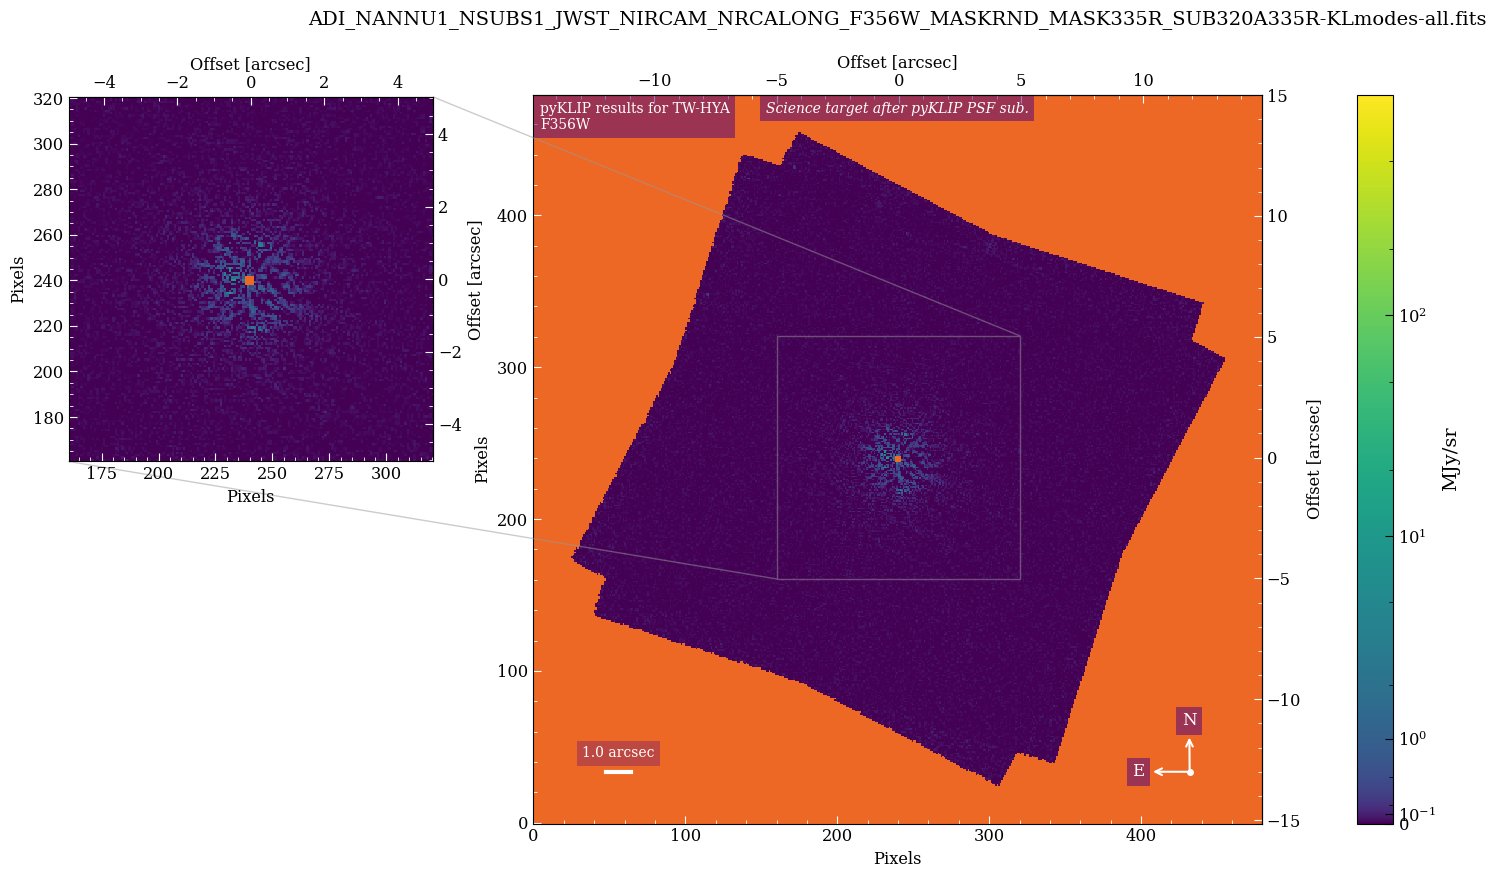

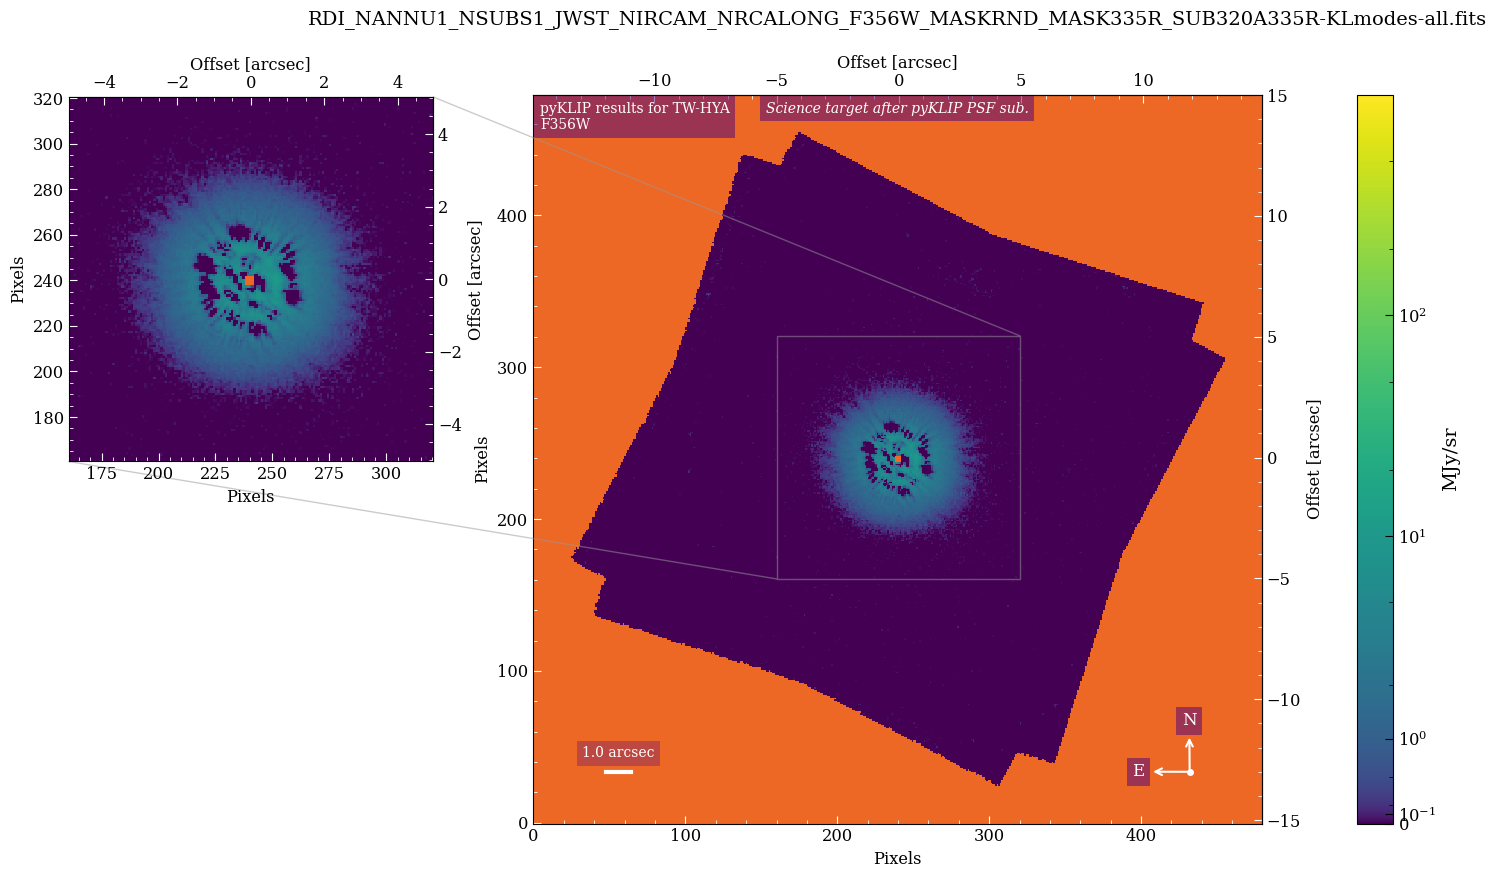

In [36]:
# show the image in PYKLIP output
spaceKLIP.plotting.display_coron_dataset(
    database,
    interactive=False,  # Static or interactive plots?
    zoom_center=3,  # Optional zoom factor; set to None to disable.
    vmin=0, vmax=1e3,  # Define the min/max values for consistent image scaling.
    save_filename='twhya_f356W_klipsub.pdf'  # Save plots to PDF.
)

# Post-Pipeline

In [3]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [4]:
import os
import glob
import numpy as np
import astropy
import astropy.table
import matplotlib.pyplot as plt
import spaceKLIP
import webbpsf_ext
webbpsf_ext.setup_logging('WARN', verbose=False)
# Name the root directory where we will keep the data for this tutorial.
data_root = 'data_nircam_twhya'
filt = 'F356W'  # Set to None to disable filter selection and load all filters.


In [5]:
# Define the directory containing the KLIP output files.
input_dir = os.path.join(data_root, 'klipsub')

# Get a sorted list of FITS files that match the filter and KLmodes pattern.
fitsfiles = sorted(glob.glob(os.path.join(input_dir, f"*{filt}*KLmodes-all.fits")))

# prioritize ADI files by switching the first and second files
fitsfiles[0], fitsfiles[1] = fitsfiles[1], fitsfiles[0]

# Initialize the SpaceKLIP database with the root data directory.
database = spaceKLIP.database.Database(output_dir=data_root)

# Read the JWST data from the FITS files into the database.
database.read_jwst_s3_data(fitsfiles)

[spaceKLIP.database:INFO] --> Identified 1 concatenation(s)
[spaceKLIP.database:INFO]   --> Concatenation 1: JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
 TYPE   EXP_TYPE DATAMODL TELESCOP ... SUBSECTS    KLMODES     BUNIT  BLURFWHM
------ --------- -------- -------- ... -------- -------------- ------ --------
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan
PYKLIP NRC_CORON   STAGE3     JWST ...        1 1,2,5,10,20,50 MJy/sr      nan


In [6]:
# Initialize the spaceKLIP contrast estimation class.
analysistools = spaceKLIP.analysistools.AnalysisTools(database)

[spaceKLIP.analysistools:INFO] Copying starfile fitted_m0v_TWHya.vot to data_nircam_twhya/rawcon/fitted_m0v_TWHya.vot
[spaceKLIP.analysistools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.analysistools:INFO] Analyzing file data_nircam_twhya/klipsub/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all.fits
[spaceKLIP.psf:INFO]   --> Generating WebbPSF model
[spaceKLIP.analysistools:INFO]   Measuring raw contrast in annuli
[spaceKLIP.analysistools:INFO]   Measuring raw contrast for masked data
[spaceKLIP.analysistools:INFO]  Plot saved in data_nircam_twhya/rawcon/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_masked.pdf


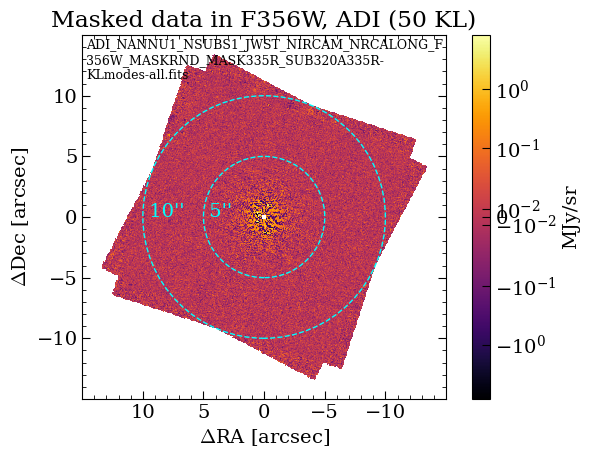

[spaceKLIP.analysistools:INFO]  Plot saved in data_nircam_twhya/rawcon/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_rawcon.pdf


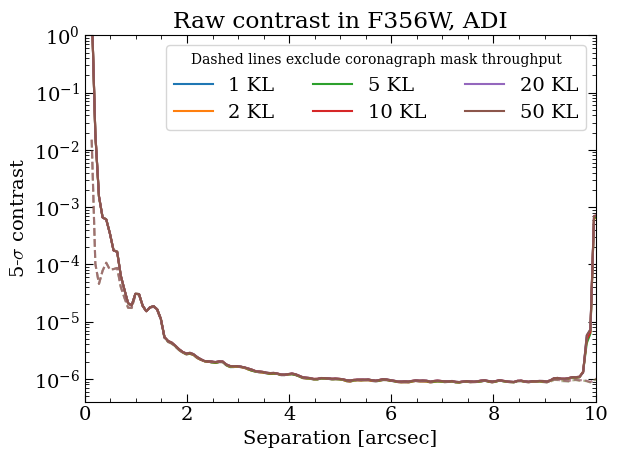

Contrast results and plots saved to data_nircam_twhya/rawcon/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_seps.npy, data_nircam_twhya/rawcon/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_cons.npy
[spaceKLIP.analysistools:INFO] Analyzing file data_nircam_twhya/klipsub/ADI+RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all.fits
[spaceKLIP.psf:INFO]   --> Generating WebbPSF model
[spaceKLIP.analysistools:INFO]   Measuring raw contrast in annuli
[spaceKLIP.analysistools:INFO]   Measuring raw contrast for masked data
[spaceKLIP.analysistools:INFO]  Plot saved in data_nircam_twhya/rawcon/ADI+RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_masked.pdf


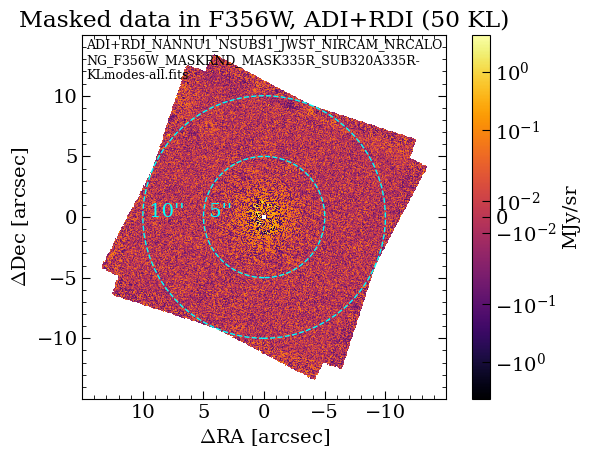

[spaceKLIP.analysistools:INFO]  Plot saved in data_nircam_twhya/rawcon/ADI+RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_rawcon.pdf


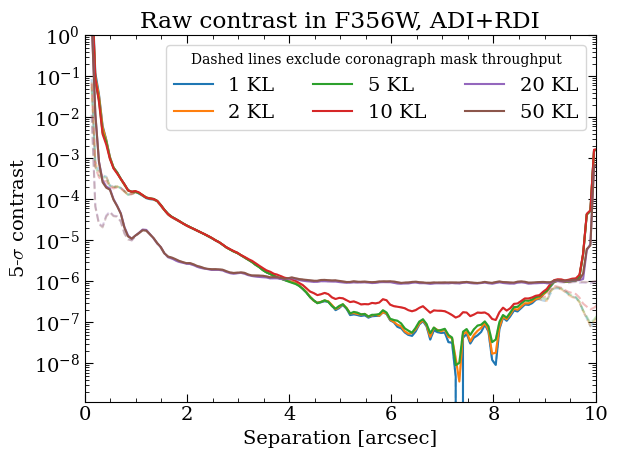

Contrast results and plots saved to data_nircam_twhya/rawcon/ADI+RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_seps.npy, data_nircam_twhya/rawcon/ADI+RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_cons.npy
[spaceKLIP.analysistools:INFO] Analyzing file data_nircam_twhya/klipsub/RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all.fits
[spaceKLIP.psf:INFO]   --> Generating WebbPSF model
[spaceKLIP.analysistools:INFO]   Measuring raw contrast in annuli
[spaceKLIP.analysistools:INFO]   Measuring raw contrast for masked data
[spaceKLIP.analysistools:INFO]  Plot saved in data_nircam_twhya/rawcon/RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_masked.pdf


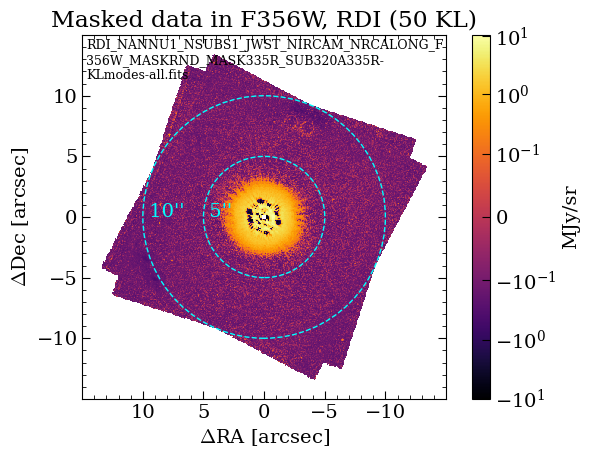

[spaceKLIP.analysistools:INFO]  Plot saved in data_nircam_twhya/rawcon/RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_rawcon.pdf


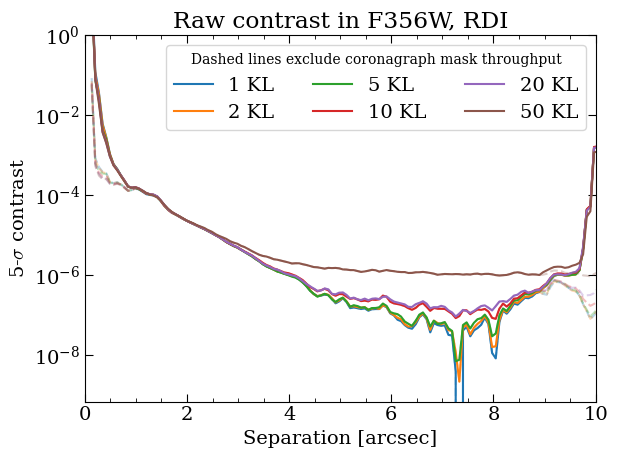

Contrast results and plots saved to data_nircam_twhya/rawcon/RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_seps.npy, data_nircam_twhya/rawcon/RDI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all_cons.npy


In [7]:
# Compute raw contrast.
star_photometry_vot = 'fitted_m0v_TWHya.vot'
star_spectral_type = 'M0V'
analysistools.raw_contrast(
    star_photometry_vot,  # Stellar photometry.
    spectral_type=star_spectral_type,  # Spectral type.
    # [RA offset (arcsec), Dec offset (arcsec), mask radius (lambda/D)].
    subdir='rawcon')

In [8]:
from astropy.io import fits
# Define the path to the FITS file
fits_file = 'data_nircam_twhya/klipsub/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all.fits'
# Open the FITS file
with fits.open(fits_file) as hdul:
    # Print the header of the first HDU
    for i in hdul[0].header:
        print(f"{i}: {hdul[0].header[i]}")

SIMPLE: True
BITPIX: -32
NAXIS: 3
NAXIS1: 480
NAXIS2: 480
NAXIS3: 6
EXTEND: True
DRPNFILE: 32
FILE_0: jw01179005001_03106_00001_nrcalong_calints.fits_INT1.fits
FILE_1: jw01179005001_03106_00001_nrcalong_calints.fits_INT10.fits
FILE_2: jw01179005001_03106_00001_nrcalong_calints.fits_INT11.fits
FILE_3: jw01179005001_03106_00001_nrcalong_calints.fits_INT12.fits
FILE_4: jw01179005001_03106_00001_nrcalong_calints.fits_INT13.fits
FILE_5: jw01179005001_03106_00001_nrcalong_calints.fits_INT14.fits
FILE_6: jw01179005001_03106_00001_nrcalong_calints.fits_INT15.fits
FILE_7: jw01179005001_03106_00001_nrcalong_calints.fits_INT16.fits
FILE_8: jw01179005001_03106_00001_nrcalong_calints.fits_INT2.fits
FILE_9: jw01179005001_03106_00001_nrcalong_calints.fits_INT3.fits
FILE_10: jw01179005001_03106_00001_nrcalong_calints.fits_INT4.fits
FILE_11: jw01179005001_03106_00001_nrcalong_calints.fits_INT5.fits
FILE_12: jw01179005001_03106_00001_nrcalong_calints.fits_INT6.fits
FILE_13: jw01179005001_03106_00001_nrc

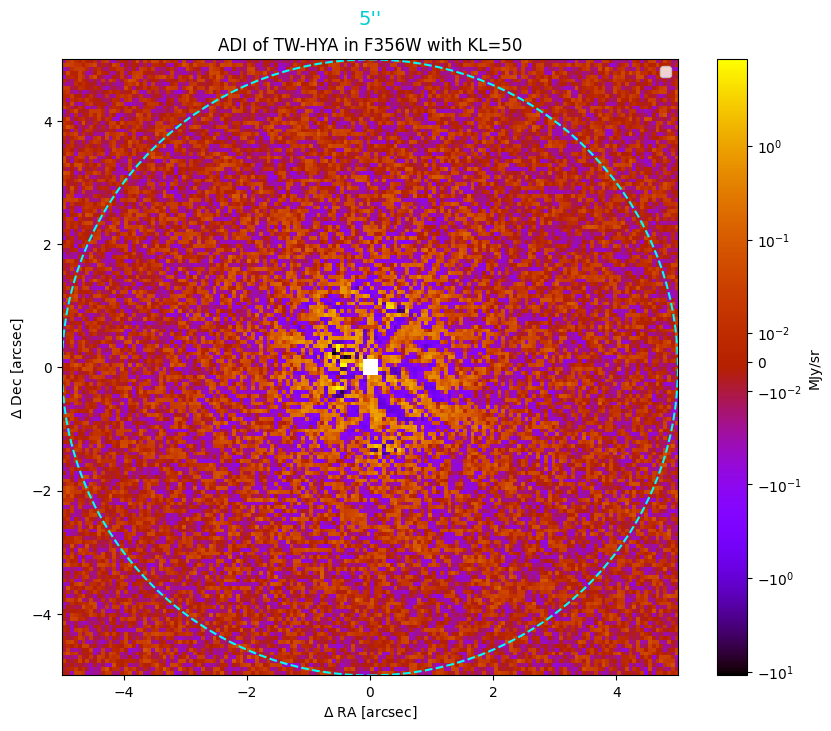

In [9]:
# Plot saved in data_nircam_twhya/klipsub/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R-KLmodes-all.fits
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np
import matplotlib.patches as patches # Added for the circle
from matplotlib.colors import SymLogNorm # Import SymLogNorm

# --- Zoom Configuration ---
# Set to a list like [-2, 2] to zoom, or None to disable zoom for that axis.
zoom_x_arcsec = [-5, 5]  # Example: [-5, 5]
zoom_y_arcsec = [-5, 5]  # Example: [-5, 5]
# --- End Zoom Configuration ---

# Define the path to the FITS file
fits_file = 'data_nircam_twhya/klipsub/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all.fits'
# Open the FITS file
with fits.open(fits_file) as hdul:
    # Load the data from the primary HDU
    data_cube = hdul[0].data
    header = hdul[0].header

    # Determine which slice to plot (user was plotting data[1], which is index 1)
    slice_index_to_plot = 5
    image_data_to_plot = data_cube[slice_index_to_plot]

    # Get necessary info from header for title and axes
    pixscale = header.get('PIXSCALE')  # arcsec/pixel
    filter_name = header.get('FILTER', 'N/A')
    reduction_mode = header.get('MODE', 'N/A')
    target_name = header.get('TARGPROP', 'N/A')
    # KL modes are stored as KLMODEn. data_cube[0] is KLMODE0, data_cube[1] is KLMODE1, etc.
    kl_mode_key = f'KLMODE{slice_index_to_plot}'
    # Use the value from the header (e.g., KLMODE1: 2 means KL=2)
    kl_mode_value = header.get(kl_mode_key, f'Slice {slice_index_to_plot+1}') 
    bunit = header.get('BUNIT', 'Pixel Value')

    # Image dimensions for the selected slice
    ny, nx = image_data_to_plot.shape

    # Center of the image in pixels (0-indexed from PSFCENTX/Y or calculated if not present)
    center_x_pix = header.get('PSFCENTX', (nx - 1) / 2.0)
    center_y_pix = header.get('PSFCENTY', (ny - 1) / 2.0)
    
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    # Determine a suitable linear threshold for SymLogNorm
    linthresh = np.percentile(np.abs(image_data_to_plot[np.isfinite(image_data_to_plot) & (image_data_to_plot != 0)]), 50)
    if linthresh == 0: # Handle cases where percentile might be zero (e.g. mostly zero image)
        linthresh = 1e-5 # A small default positive value
    #linthresh = 0.03
    
    # Determine vmin and vmax for SymLogNorm to cover the data range
    data_min = np.nanmin(image_data_to_plot)
    data_max = np.nanmax(image_data_to_plot)
    #data_min = -10
    #data_max = 10

    if pixscale is not None:
        x_min_arcsec = (-0.5 - center_x_pix) * pixscale
        x_max_arcsec = (nx - 0.5 - center_x_pix) * pixscale
        y_min_arcsec = (-0.5 - center_y_pix) * pixscale # bottom for origin='lower'
        y_max_arcsec = (ny - 0.5 - center_y_pix) * pixscale # top for origin='lower'
        extent_arcsec = [x_min_arcsec, x_max_arcsec, y_min_arcsec, y_max_arcsec]

        plt.imshow(image_data_to_plot, cmap='gnuplot', origin='lower', extent=extent_arcsec, 
                   norm=SymLogNorm(linthresh=linthresh, linscale=0.5, vmin=data_min, vmax=data_max, base=10))
        plt.colorbar(label=bunit)
        
        title_str = f'{reduction_mode} of {target_name} in {filter_name} with KL={kl_mode_value}'
        plt.title(title_str)
        plt.xlabel(r'$\Delta$ RA [arcsec]')
        plt.ylabel(r'$\Delta$ Dec [arcsec]')

        reference_circle_radius = 5  # arcsec
        circle = patches.Circle((0, 0), reference_circle_radius, edgecolor='aqua', facecolor='none', linestyle='--', linewidth=1.5)
        ax.add_patch(circle)
        # add a text label for the circle
        circle_label = f'{reference_circle_radius}\'\''
        ax.text(0, reference_circle_radius + 0.5, circle_label, color='darkturquoise', fontsize=14, ha='center', va='bottom')
        ax.set_aspect('equal', adjustable='box')
        plt.legend() # Add legend to display circle label

        # Apply zoom if specified
        if zoom_x_arcsec is not None:
            ax.set_xlim(zoom_x_arcsec)
        if zoom_y_arcsec is not None:
            ax.set_ylim(zoom_y_arcsec)
    else:
        # Fallback to pixel units if pixscale is not available
        print("Warning: PIXSCALE not found in FITS header. Plotting in pixel units.")
        plt.imshow(image_data_to_plot, cmap='gnuplot', origin='lower',
                   norm=SymLogNorm(linthresh=linthresh, linscale=0.5, vmin=data_min, vmax=data_max, base=10))
        plt.colorbar(label=bunit) 
        title_str = f'{filter_name} - {reduction_mode} - KL={kl_mode_value} (Pixel Units)'
        plt.title(title_str)
        plt.xlabel('X Pixel')
        plt.ylabel('Y Pixel')
        # Note: Zoom in arcseconds is not applicable here as pixscale is missing.

    plt.show()


In [9]:
target_seps =  np.linspace(0.5, 4.5, 9).tolist() # Separation range for contrast estimation.
target_pas = np.linspace(0, 330, 12).tolist() # Position angle range for contrast estimation.

#Compute calibrated contrast.
analysistools.calibrate_contrast(
    rawcon_subdir='rawcon', # Directory raw contrasts are saved to.
    # [RA offset (arcsec), Dec offset (arcsec), mask radius (lambda/D)].
    injection_seps=target_seps, # arcsec
    injection_pas=target_pas,  # degrees
    injection_flux_sigma=20,
    # Spacing between injected companion, None = 1 companion per injection+recovery.
    multi_injection_spacing=None,
    use_saved=False,  # Useful for debugging / changing plots / sharing files.
    subdir='calcon')  # Save directory.

[spaceKLIP.analysistools:INFO] --> Concatenation JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
[spaceKLIP.psf:INFO]   --> Generating WebbPSF model
[spaceKLIP.analysistools:INFO] Analyzing file data_nircam_twhya/klipsub/ADI_NANNU1_NSUBS1_JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R-KLmodes-all.fits
[spaceKLIP.analysistools:INFO] Injecting and recovering synthetic companions. This may take a while...
[spaceKLIP.analysistools:INFO] --> All 108 source positions suitable for injection.


  0%|          | 0/108 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]